<a href="https://colab.research.google.com/github/anjineyulutv/Amazon_Fine_Food_Reviews/blob/master/HR_Interview_copilot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

## Google Colab is available in VS Code!
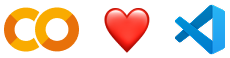

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

In [1]:
!pip install google-generativeai openai reportlab google-cloud-texttospeech gradio pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.6 MB/s eta 0:00:00


In [2]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/drive/MyDrive/anjuedtechcopilot-b29b5ab38fcc.json"

In [3]:
!pip install google-cloud-texttospeech

In [4]:
from google.cloud import texttospeech

client = texttospeech.TextToSpeechClient()

print("Authentication successful ✅")

Authentication successful ✅


In [5]:
from google.cloud import texttospeech

client = texttospeech.TextToSpeechClient()

input_text = texttospeech.SynthesisInput(text="Hello, this is a test from Google Cloud TTS.")

voice = texttospeech.VoiceSelectionParams(
    language_code="en-US",
    name="en-US-Wavenet-D"
)

audio_config = texttospeech.AudioConfig(
    audio_encoding=texttospeech.AudioEncoding.MP3
)

response = client.synthesize_speech(
    input=input_text,
    voice=voice,
    audio_config=audio_config
)

with open("output.mp3", "wb") as out:
    out.write(response.audio_content)

print("Audio file generated ✅")

Audio file generated ✅


In [10]:
from IPython.display import Audio
Audio("output.mp3")

In [11]:
import os
import json
import uuid
import tempfile
import google.generativeai as genai
from openai import OpenAI
import gradio as gr
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, PageBreak
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from google.cloud import texttospeech

In [9]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!pip install google-cloud-texttospeech google-cloud-aiplatform

In [15]:
import os
import vertexai
from vertexai.generative_models import GenerativeModel
from google.cloud import texttospeech
from google.cloud import speech
from IPython.display import Audio

PROJECT_ID = "anjuedtechcopilot"
REGION = "us-central1"

vertexai.init(project=PROJECT_ID, location=REGION)

gemini_model = GenerativeModel("gemini-1.5-flash")
tts_client = texttospeech.TextToSpeechClient()
stt_client = speech.SpeechClient()

print("All services initialized ✅")

All services initialized ✅


/usr/local/lib/python3.12/dist-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [16]:
def generate_question(topic, difficulty="medium"):
    prompt = f"""
    You are a professional technical interviewer.

    Generate ONE {difficulty} level interview question on {topic}.
    Do not provide explanation.
    Only return the question.
    """

    response = gemini_model.generate_content(prompt)
    return response.text.strip()

In [17]:
def text_to_speech(text, filename="question.mp3"):
    synthesis_input = texttospeech.SynthesisInput(text=text)

    voice = texttospeech.VoiceSelectionParams(
        language_code="en-US",
        name="en-US-Wavenet-D"
    )

    audio_config = texttospeech.AudioConfig(
        audio_encoding=texttospeech.AudioEncoding.MP3
    )

    response = tts_client.synthesize_speech(
        input=synthesis_input,
        voice=voice,
        audio_config=audio_config
    )

    with open(filename, "wb") as out:
        out.write(response.audio_content)

    return filename

In [18]:
def speech_to_text(audio_file):
    with open(audio_file, "rb") as f:
        content = f.read()

    audio = speech.RecognitionAudio(content=content)

    config = speech.RecognitionConfig(
        encoding=speech.RecognitionConfig.AudioEncoding.LINEAR16,
        language_code="en-US"
    )

    response = stt_client.recognize(config=config, audio=audio)

    transcript = ""
    for result in response.results:
        transcript += result.alternatives[0].transcript

    return transcript

In [19]:
def evaluate_answer(question, answer):
    prompt = f"""
    You are a senior technical interviewer.

    Question:
    {question}

    Candidate Answer:
    {answer}

    Evaluate the answer based on:
    1. Technical Accuracy (0-10)
    2. Clarity (0-10)
    3. Depth (0-10)

    Provide:
    - Individual scores
    - Final score out of 30
    - 3 strengths
    - 3 improvement areas
    """

    response = gemini_model.generate_content(prompt)
    return response.text.strip()

In [20]:
def run_interview(topic="Machine Learning", num_questions=2):
    interview_summary = []

    for i in range(num_questions):
        print(f"\n========== Question {i+1} ==========")

        # Generate question
        question = generate_question(topic)
        print("\nInterviewer Question:")
        print(question)

        # Convert to speech
        audio_file = text_to_speech(question, f"question_{i+1}.mp3")
        display(Audio(audio_file))

        print("\nUpload candidate answer as WAV file (LINEAR16 format)")

        from google.colab import files
        uploaded = files.upload()
        answer_file = list(uploaded.keys())[0]

        # Convert speech to text
        answer_text = speech_to_text(answer_file)
        print("\nCandidate Answer (Transcribed):")
        print(answer_text)

        # Evaluate answer
        evaluation = evaluate_answer(question, answer_text)

        print("\nEvaluation:")
        print(evaluation)

        interview_summary.append({
            "question": question,
            "answer": answer_text,
            "evaluation": evaluation
        })

    return interview_summary

In [21]:
summary = run_interview(topic="Data Science", num_questions=2)


========== Question 1 ==========


PermissionDenied: 403 Permission 'aiplatform.endpoints.predict' denied on resource '//aiplatform.googleapis.com/projects/anjuedtechcopilot/locations/us-central1/publishers/google/models/gemini-1.5-flash' (or it may not exist). [reason: "IAM_PERMISSION_DENIED"
domain: "aiplatform.googleapis.com"
metadata {
  key: "resource"
  value: "projects/anjuedtechcopilot/locations/us-central1/publishers/google/models/gemini-1.5-flash"
}
metadata {
  key: "permission"
  value: "aiplatform.endpoints.predict"
}
]